# ATOM Sumo: Detailed Test Results Analysis

This notebook collects and visualizes the main measured test evidence for the `ATOM Sumo` prototype.

Covered datasets:

- HTTP control latency
- straight-line speed
- straightness / drift
- turn-in-place timing
- automatic ToF stop-distance behavior
- static ToF accuracy
- power brownout / reset behavior

The notebook is intended as the main Jupyter evidence file for Verstapost review.


In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
candidates = [
    cwd / "tests" / "results",   # repository root
    cwd / "results",             # tests folder
    cwd.parent / "results",      # tests/notebooks folder
    cwd / "analysis" / "results",# legacy repository root
]
for candidate in candidates:
    if candidate.exists():
        RESULTS = candidate
        ROOT = candidate.parent.parent if candidate.parent.name == "tests" else candidate.parent
        break
else:
    raise FileNotFoundError(
        "Could not find test results. Run this notebook from the repository root, tests folder, or tests/notebooks folder."
    )

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

def read_csv(name):
    path = RESULTS / name
    df = pd.read_csv(path)
    return df

csv_files = sorted(RESULTS.glob("*.csv"))
inventory = pd.DataFrame(
    {
        "file": [p.name for p in csv_files],
        "rows": [len(pd.read_csv(p)) for p in csv_files],
        "bytes": [p.stat().st_size for p in csv_files],
    }
)
inventory


,file,rows,bytes
0,http_latency_2026-04-11_18-28-33.csv,120,3889
1,http_latency_2026-04-11_19-34-31.csv,120,3827
2,http_latency_2026-04-11_19-38-18_medium_speed.csv,120,3887
3,http_latency_2026-05-30_15-40-08_speed0.csv,120,3813
4,http_latency_2026-05-30_15-41-58_speed0.csv,120,3816
5,http_latency_2026-05-30_15-42-18_speed180.csv,120,3828
6,movement_drift_test.csv,14,485
7,movement_speed_test.csv,12,454
8,movement_turn_test.csv,18,629
9,power_brownout_test.csv,40,3539


## 1. HTTP Control Latency

The latency tests measure request-response time for `/move?dir=forward` and `/move?dir=stop`.
They are control-path measurements, not physical wheel-start measurements.


In [2]:
latency_runs = {
    "2026-04-11 pre-fix speed0": "http_latency_2026-04-11_18-28-33.csv",
    "2026-04-11 fixed speed0": "http_latency_2026-04-11_19-34-31.csv",
    "2026-04-11 fixed speed180": "http_latency_2026-04-11_19-38-18_medium_speed.csv",
    "2026-05-30 speed0 run1": "http_latency_2026-05-30_15-40-08_speed0.csv",
    "2026-05-30 speed0 run2": "http_latency_2026-05-30_15-41-58_speed0.csv",
    "2026-05-30 speed180": "http_latency_2026-05-30_15-42-18_speed180.csv",
}

latency_frames = []
summary_rows = []
endpoint_rows = []

for label, filename in latency_runs.items():
    df = read_csv(filename)
    df["run"] = label
    latency_frames.append(df)
    summary_rows.append(
        {
            "run": label,
            "count": len(df),
            "median_ms": df["latency_ms"].median(),
            "p95_ms": df["latency_ms"].quantile(0.95),
            "max_ms": df["latency_ms"].max(),
        }
    )
    for endpoint, group in df.groupby("endpoint"):
        endpoint_rows.append(
            {
                "run": label,
                "endpoint": endpoint,
                "count": len(group),
                "median_ms": group["latency_ms"].median(),
                "p95_ms": group["latency_ms"].quantile(0.95),
                "max_ms": group["latency_ms"].max(),
            }
        )

latency_all = pd.concat(latency_frames, ignore_index=True)
latency_summary = pd.DataFrame(summary_rows)
endpoint_summary = pd.DataFrame(endpoint_rows)
latency_summary.round(3)


,run,count,median_ms,p95_ms,max_ms
0,2026-04-11 pre-fix speed0,120,127.809,162.072,274.227
1,2026-04-11 fixed speed0,120,31.538,53.178,68.883
2,2026-04-11 fixed speed180,120,87.372,158.048,186.038
3,2026-05-30 speed0 run1,120,18.565,42.344,73.677
4,2026-05-30 speed0 run2,120,17.319,54.800,71.143
5,2026-05-30 speed180,120,65.684,82.119,101.888


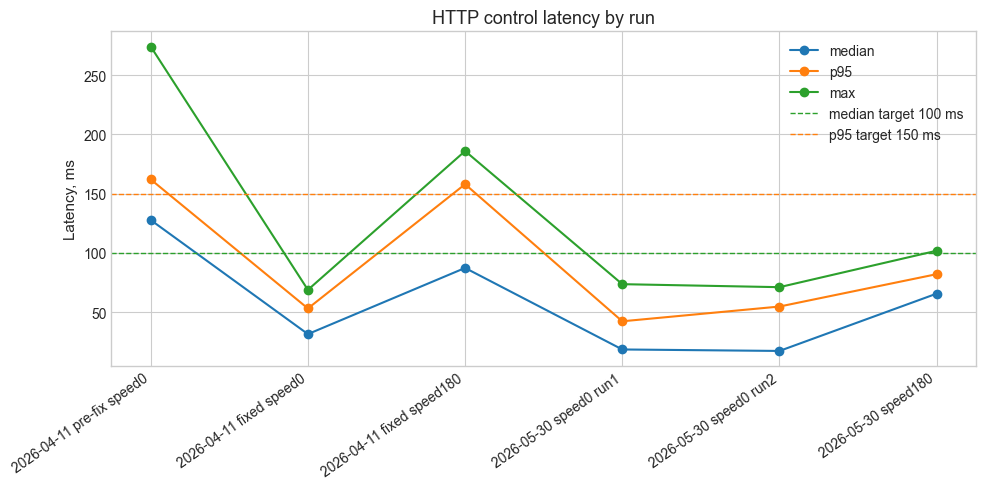

In [3]:
fig, ax = plt.subplots()
x = range(len(latency_summary))
ax.plot(x, latency_summary["median_ms"], marker="o", label="median")
ax.plot(x, latency_summary["p95_ms"], marker="o", label="p95")
ax.plot(x, latency_summary["max_ms"], marker="o", label="max")
ax.axhline(100, color="tab:green", linestyle="--", linewidth=1, label="median target 100 ms")
ax.axhline(150, color="tab:orange", linestyle="--", linewidth=1, label="p95 target 150 ms")
ax.set_xticks(list(x))
ax.set_xticklabels(latency_summary["run"], rotation=35, ha="right")
ax.set_ylabel("Latency, ms")
ax.set_title("HTTP control latency by run")
ax.legend()
plt.tight_layout()
plt.show()


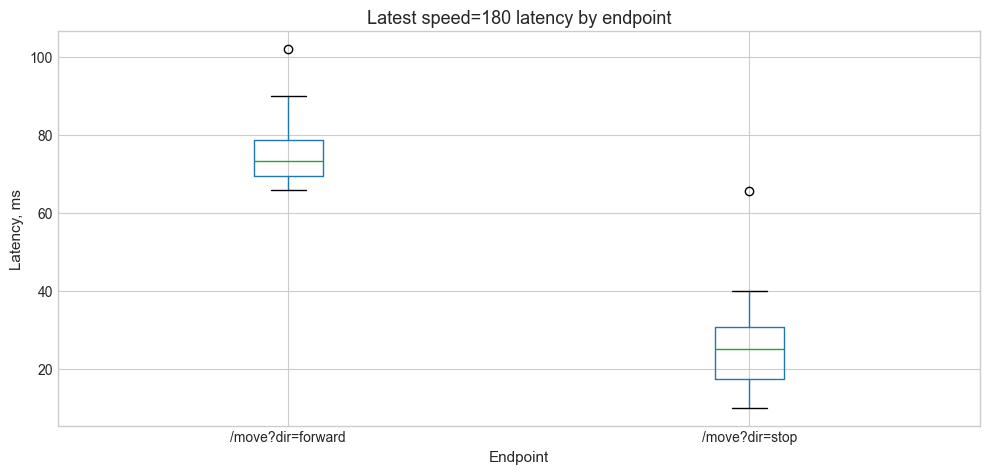

,run,endpoint,count,median_ms,p95_ms,max_ms
0,2026-04-11 pre-fix speed0,/move?dir=forward,60,138.029,167.943,274.227
1,2026-04-11 pre-fix speed0,/move?dir=stop,60,18.833,78.363,125.706
2,2026-04-11 fixed speed0,/move?dir=forward,60,30.623,53.178,68.883
3,2026-04-11 fixed speed0,/move?dir=stop,60,32.673,51.061,67.651
4,2026-04-11 fixed speed180,/move?dir=forward,60,147.644,167.672,186.038
5,2026-04-11 fixed speed180,/move?dir=stop,60,32.405,39.333,44.610
6,2026-05-30 speed0 run1,/move?dir=forward,60,15.614,38.092,67.271
7,2026-05-30 speed0 run1,/move?dir=stop,60,21.866,43.140,73.677
8,2026-05-30 speed0 run2,/move?dir=forward,60,16.644,31.771,62.663
9,2026-05-30 speed0 run2,/move?dir=stop,60,18.345,58.765,71.143


In [4]:
latest = latency_all[latency_all["run"] == "2026-05-30 speed180"]
fig, ax = plt.subplots()
latest.boxplot(column="latency_ms", by="endpoint", ax=ax)
ax.set_title("Latest speed=180 latency by endpoint")
ax.set_xlabel("Endpoint")
ax.set_ylabel("Latency, ms")
plt.suptitle("")
plt.tight_layout()
plt.show()

endpoint_summary.round(3)


## 2. Movement Speed

The speed test measures time over a straight `1.0 m` path at several PWM values.


In [5]:
speed = read_csv("movement_speed_test.csv")
speed_summary = (
    speed.groupby("pwm")
    .agg(
        trials=("speed_m_s", "count"),
        mean_speed_m_s=("speed_m_s", "mean"),
        std_speed_m_s=("speed_m_s", "std"),
        min_speed_m_s=("speed_m_s", "min"),
        max_speed_m_s=("speed_m_s", "max"),
    )
    .reset_index()
)
speed_summary.round(3)


,pwm,trials,mean_speed_m_s,std_speed_m_s,min_speed_m_s,max_speed_m_s
0,80,3,0.205,0.004,0.201,0.208
1,150,3,0.385,0.003,0.382,0.388
2,180,3,0.465,0.010,0.455,0.474
3,255,3,0.610,0.034,0.578,0.645


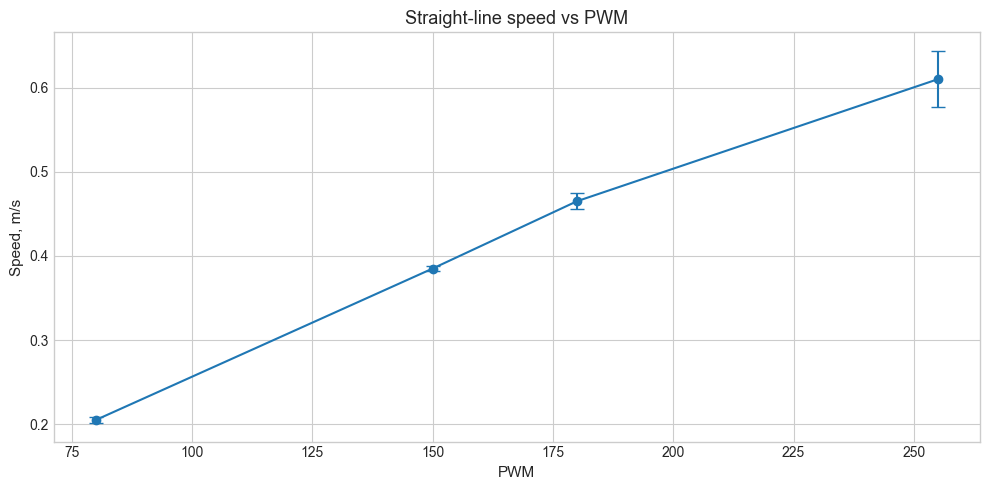

In [6]:
fig, ax = plt.subplots()
ax.errorbar(
    speed_summary["pwm"],
    speed_summary["mean_speed_m_s"],
    yerr=speed_summary["std_speed_m_s"].fillna(0),
    fmt="o-",
    capsize=5,
)
ax.set_title("Straight-line speed vs PWM")
ax.set_xlabel("PWM")
ax.set_ylabel("Speed, m/s")
plt.tight_layout()
plt.show()


## 3. Straightness / Drift

Drift is measured after a `1.0 m` forward run. Positive values below are shown as left/right categories.


In [7]:
drift = read_csv("movement_drift_test.csv")
drift_summary = (
    drift.groupby(["pwm", "direction"])
    .agg(trials=("drift_cm", "count"), mean_drift_cm=("drift_cm", "mean"), max_drift_cm=("drift_cm", "max"))
    .reset_index()
)
drift_summary.round(2)


,pwm,direction,trials,mean_drift_cm,max_drift_cm
0,80,left,3,8.03,8.4
1,150,left,3,11.17,14.3
2,180,left,4,7.70,9.8
3,255,left,3,5.63,6.8
4,255,right,1,1.60,1.6


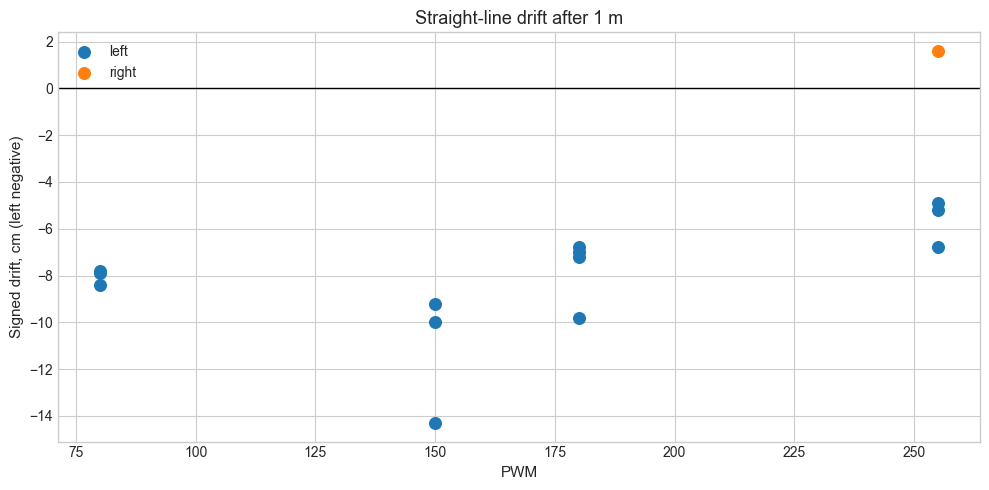

In [8]:
fig, ax = plt.subplots()
for direction, group in drift.groupby("direction"):
    signed = group["drift_cm"] * (-1 if direction == "left" else 1)
    ax.scatter(group["pwm"], signed, label=direction, s=70)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Straight-line drift after 1 m")
ax.set_xlabel("PWM")
ax.set_ylabel("Signed drift, cm (left negative)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Turn-In-Place Timing

Turn tests record time for approximate `180 deg` turns in both directions.


In [9]:
turn = read_csv("movement_turn_test.csv")
turn_summary = (
    turn.groupby(["pwm", "direction"])
    .agg(trials=("time_s", "count"), mean_time_s=("time_s", "mean"), std_time_s=("time_s", "std"))
    .reset_index()
)
turn_summary.round(3)


,pwm,direction,trials,mean_time_s,std_time_s
0,150,left,3,0.867,0.091
1,150,right,3,0.997,0.035
2,180,left,3,0.733,0.035
3,180,right,3,0.740,0.085
4,255,left,3,0.597,0.121
5,255,right,3,0.647,0.050


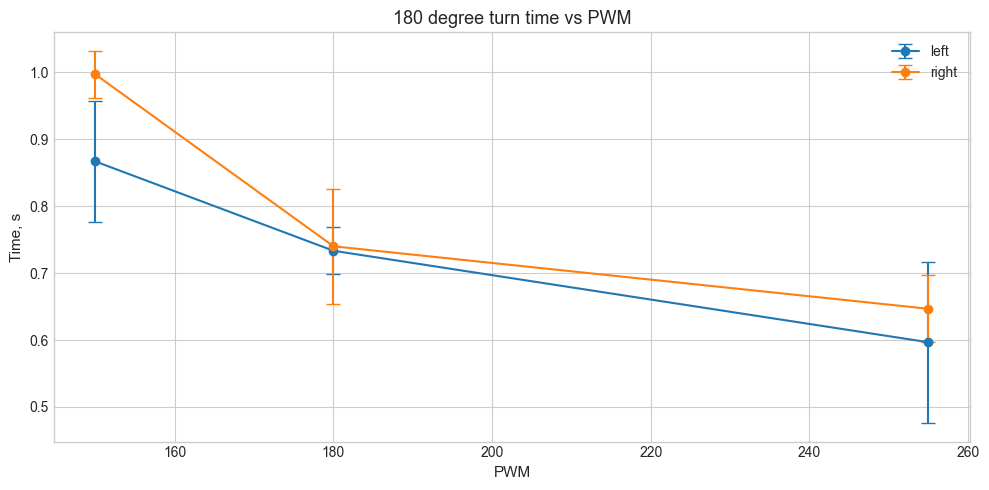

In [10]:
fig, ax = plt.subplots()
for direction, group in turn_summary.groupby("direction"):
    ax.errorbar(group["pwm"], group["mean_time_s"], yerr=group["std_time_s"].fillna(0), marker="o", capsize=5, label=direction)
ax.set_title("180 degree turn time vs PWM")
ax.set_xlabel("PWM")
ax.set_ylabel("Time, s")
ax.legend()
plt.tight_layout()
plt.show()


## 5. ToF Automatic Stop-Distance Test

This is the main stop-distance evidence. The robot drives toward an obstacle with ToF stop enabled and the final distance is recorded.


In [11]:
tof_stop = read_csv("tof_stop_test.csv")
tof_stop_summary = (
    tof_stop.groupby(["pwm", "threshold_mm", "result"])
    .agg(trials=("actual_stop_distance_cm", "count"), mean_stop_cm=("actual_stop_distance_cm", "mean"), min_stop_cm=("actual_stop_distance_cm", "min"))
    .reset_index()
)
tof_stop_summary.round(2)


,pwm,threshold_mm,result,trials,mean_stop_cm,min_stop_cm
0,80,250,stopped,3,10.57,10.2
1,80,300,stopped,3,17.53,16.0
2,80,400,stopped,3,27.23,26.5
3,150,400,stopped,3,12.90,11.6
4,255,400,collision,1,7.20,7.2


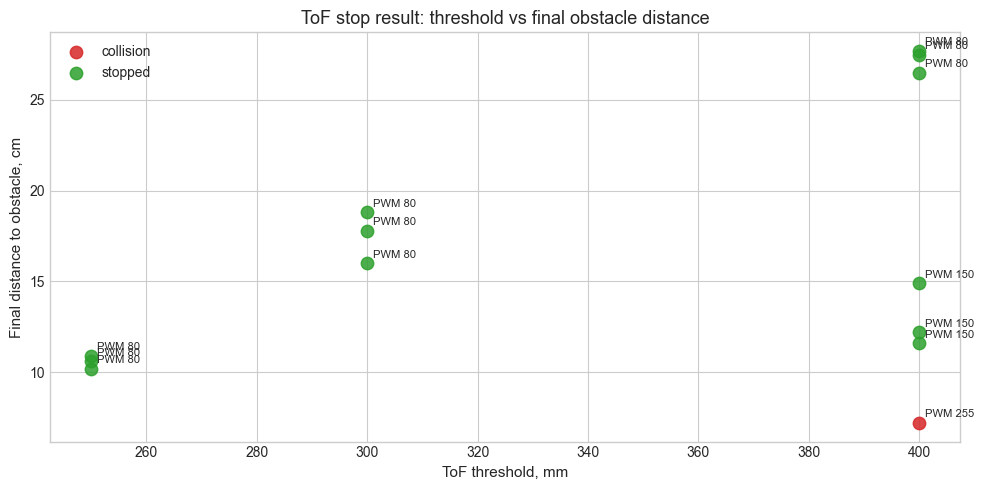

In [12]:
fig, ax = plt.subplots()
colors = {"stopped": "tab:green", "collision": "tab:red"}
for result, group in tof_stop.groupby("result"):
    ax.scatter(
        group["threshold_mm"],
        group["actual_stop_distance_cm"],
        s=80,
        c=colors.get(result, "tab:gray"),
        label=result,
        alpha=0.85,
    )
    for _, row in group.iterrows():
        ax.annotate(f"PWM {row['pwm']}", (row["threshold_mm"], row["actual_stop_distance_cm"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_title("ToF stop result: threshold vs final obstacle distance")
ax.set_xlabel("ToF threshold, mm")
ax.set_ylabel("Final distance to obstacle, cm")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Static ToF Accuracy

Static ToF readings are compared against known distances. The current dataset shows that the sensor responds, but has a large mounting/calibration offset.


In [13]:
tof_acc = read_csv("tof_accuracy_test.csv")
tof_acc_summary = (
    tof_acc.groupby("actual_mm")
    .agg(
        trials=("measured_mm", "count"),
        mean_measured_mm=("measured_mm", "mean"),
        mean_error_mm=("error_mm", "mean"),
        min_error_mm=("error_mm", "min"),
        max_error_mm=("error_mm", "max"),
    )
    .reset_index()
)
tof_acc_summary.round(1)


,actual_mm,trials,mean_measured_mm,mean_error_mm,min_error_mm,max_error_mm
0,50,3,113.7,63.7,62,65
1,100,3,170.3,70.3,66,77
2,200,3,271.3,71.3,63,76
3,300,3,331.0,31.0,26,35
4,500,3,362.3,-137.7,-210,-45


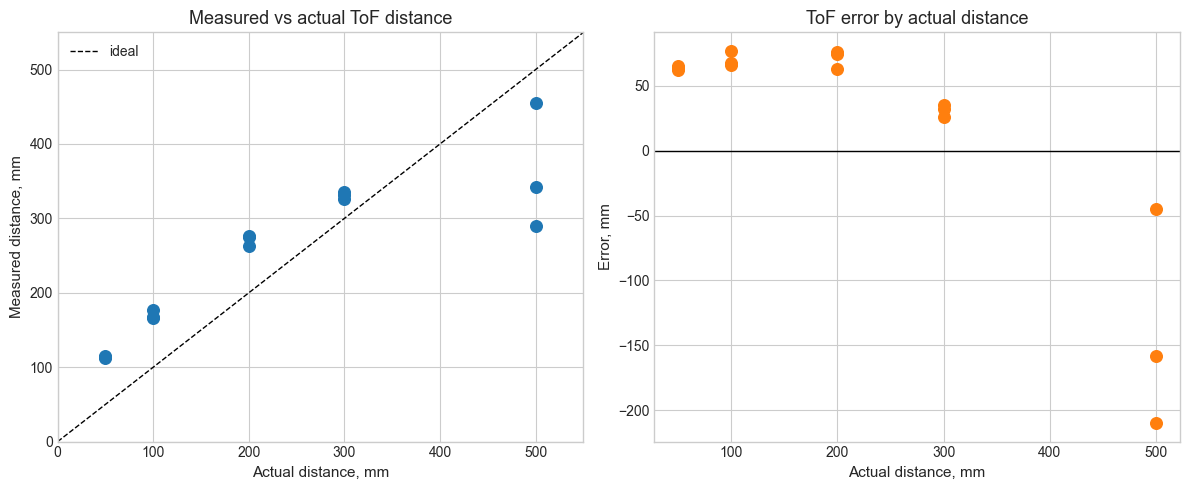

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(tof_acc["actual_mm"], tof_acc["measured_mm"], s=70)
lim = [0, max(tof_acc["actual_mm"].max(), tof_acc["measured_mm"].max()) + 50]
ax1.plot(lim, lim, "k--", linewidth=1, label="ideal")
ax1.set_xlim(lim)
ax1.set_ylim(lim)
ax1.set_title("Measured vs actual ToF distance")
ax1.set_xlabel("Actual distance, mm")
ax1.set_ylabel("Measured distance, mm")
ax1.legend()

ax2.axhline(0, color="black", linewidth=1)
ax2.scatter(tof_acc["actual_mm"], tof_acc["error_mm"], s=70, color="tab:orange")
ax2.set_title("ToF error by actual distance")
ax2.set_xlabel("Actual distance, mm")
ax2.set_ylabel("Error, mm")
plt.tight_layout()
plt.show()


## 7. Power Brownout / Reset Test

The power test sends movement commands at several PWM settings and checks whether the main controller, Wi-Fi, cameras, or color endpoint fail during the run.

Important interpretation:

- `reset_observed = no` and `wifi_disconnect = no` are good for the main controller.
- `camera_loss = yes` means camera endpoints were not reachable during this test and should be re-tested with cameras confirmed online.


In [15]:
brownout = read_csv("power_brownout_test.csv")
brownout_summary = (
    brownout.groupby(["pwm", "command"])
    .agg(
        trials=("trial", "count"),
        resets=("reset_observed", lambda s: (s != "no").sum()),
        wifi_disconnects=("wifi_disconnect", lambda s: (s == "yes").sum()),
        camera_losses=("camera_loss", lambda s: (s == "yes").sum()),
    )
    .reset_index()
)
brownout_summary


,pwm,command,trials,resets,wifi_disconnects,camera_losses
0,80,backward,2,0,0,2
1,80,forward,2,0,0,2
2,80,left,2,0,0,2
3,80,right,2,0,0,2
4,80,stop,2,0,0,2
5,150,backward,2,0,0,2
6,150,forward,2,0,0,2
7,150,left,2,0,0,2
8,150,right,2,0,0,2
9,150,stop,2,0,0,2


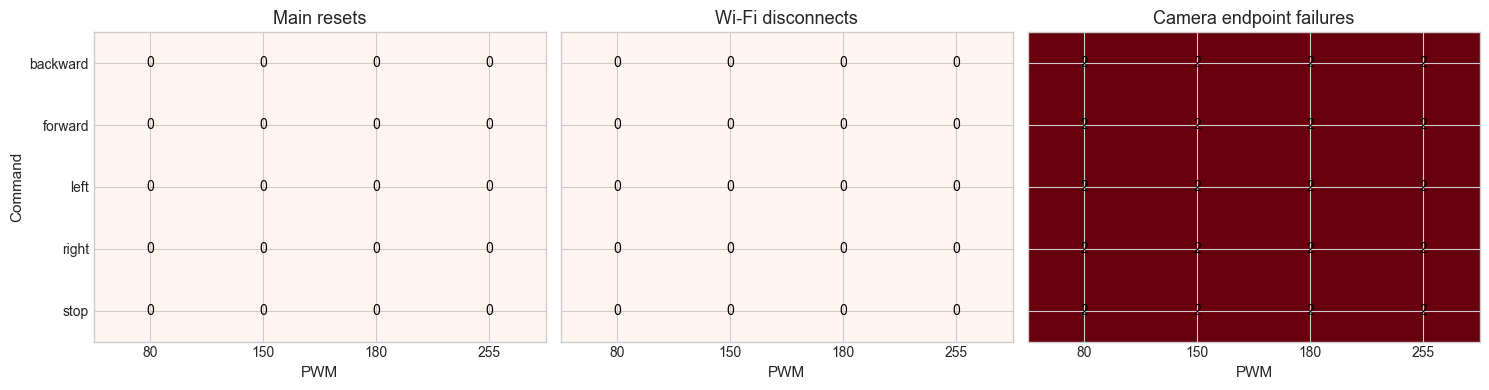

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
metrics = [
    ("resets", "Main resets"),
    ("wifi_disconnects", "Wi-Fi disconnects"),
    ("camera_losses", "Camera endpoint failures"),
]
for ax, (metric, title) in zip(axes, metrics):
    pivot = brownout_summary.pivot(index="command", columns="pwm", values=metric).fillna(0)
    im = ax.imshow(pivot.values, aspect="auto", cmap="Reds", vmin=0)
    ax.set_title(title)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("PWM")
    for y in range(pivot.shape[0]):
        for x in range(pivot.shape[1]):
            ax.text(x, y, int(pivot.values[y, x]), ha="center", va="center", color="black")
axes[0].set_ylabel("Command")
plt.tight_layout()
plt.show()


## 8. Current Engineering Conclusions

- The web command path is measured and usable for manual operation.
- The robot has movement evidence for speed, drift, and turning.
- ToF automatic stop works at moderate speed, but high-speed stopping needs threshold/speed tuning.
- Static ToF measurements show a large offset/error, so calibration or sensor placement must be addressed.
- The 4WD power test did not show main-controller reset or Wi-Fi disconnect in the available rows.
- Camera endpoint failures during the brownout test require a repeat test with Cam1/Cam2 confirmed online.
- The strongest remaining missing tests are color repeatability, tap-drive accuracy, enclosure heat/impact, and match endurance.
